# 가격 기반 Walk-Forward 분석 노트북

뉴스 없이 가격 데이터만으로 기술적 특성을 만들고, 과거 시점에서 반복 재학습/예측/평가하는 연구용 노트북입니다.

## 개요

- 입력 데이터: `price_master_history.csv`
- 예측 대상: `1D / 5D / 30D`
- 방식: 과거 시점별 walk-forward 재학습
- 출력: 현재 추천, 누적 로그, 만기 평가, 날짜별 적중률 시각화


In [1]:
from pathlib import Path
import json
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
WORKSPACE_ROOT = Path.cwd()
if (WORKSPACE_ROOT / "1_data_collection.ipynb").exists() or (WORKSPACE_ROOT / "3_advanced_analysis.ipynb").exists():
    STOCK_ANALYSIS_DIR = WORKSPACE_ROOT
elif (WORKSPACE_ROOT / "Stock_analysis" / "1_data_collection.ipynb").exists():
    STOCK_ANALYSIS_DIR = WORKSPACE_ROOT / "Stock_analysis"
else:
    STOCK_ANALYSIS_DIR = WORKSPACE_ROOT / "Stock_analysis"

DATA_DIR = STOCK_ANALYSIS_DIR / "data" / "event_driven_stock_predictor"
LONG_PRICE_MASTER_PATH = DATA_DIR / "long_price_master_history.csv"
DEFAULT_PRICE_MASTER_PATH = DATA_DIR / "price_master_history.csv"
PRICE_MASTER_PATH = LONG_PRICE_MASTER_PATH if LONG_PRICE_MASTER_PATH.exists() else DEFAULT_PRICE_MASTER_PATH
PREDICTION_LOG_PATH = DATA_DIR / "price_walkforward_prediction_log.csv"
PREDICTION_EVAL_PATH = DATA_DIR / "price_walkforward_prediction_eval.csv"
CURRENT_PREDICTION_PATH = DATA_DIR / "price_walkforward_current_predictions.csv"

FORECAST_HORIZONS = [1, 5, 30]
PRIMARY_FORECAST_HORIZON = 30
MIN_TRAIN_ROWS = 180
LOOKBACK_EVAL_DATES = 40
TOP_N = 12

print(f"Stock analysis dir: {STOCK_ANALYSIS_DIR}")
print(f"Long price path: {LONG_PRICE_MASTER_PATH}")
print(f"Selected price path: {PRICE_MASTER_PATH}")
print(f"Forecast horizons: {FORECAST_HORIZONS} (primary={PRIMARY_FORECAST_HORIZON}d)")

Stock analysis dir: c:\Users\user\Documents\GitHub\GB_practicing\Stock_analysis
Long price path: c:\Users\user\Documents\GitHub\GB_practicing\Stock_analysis\data\event_driven_stock_predictor\long_price_master_history.csv
Selected price path: c:\Users\user\Documents\GitHub\GB_practicing\Stock_analysis\data\event_driven_stock_predictor\long_price_master_history.csv
Forecast horizons: [1, 5, 30] (primary=30d)


## 가격 마스터 데이터 로드

In [3]:
assert PRICE_MASTER_PATH.exists(), f"Missing price master: {PRICE_MASTER_PATH}"
df_price_raw = pd.read_csv(PRICE_MASTER_PATH)
display(df_price_raw.head())
print(df_price_raw.shape)
print(df_price_raw.columns.tolist())

,date,open,high,low,close,adj_close,volume,symbol,asset_name,category
0,1996-03-27 00:00:00+00:00,0.207589,0.225446,0.205357,0.225446,0.189141,429296000,AAPL,Apple,MegaCap_Tech
1,1996-03-28 00:00:00+00:00,0.220982,0.228795,0.215402,0.215960,0.181183,295892800,AAPL,Apple,MegaCap_Tech
2,1996-03-29 00:00:00+00:00,0.216518,0.220982,0.212054,0.219308,0.183992,166521600,AAPL,Apple,MegaCap_Tech
3,1996-04-01 00:00:00+00:00,0.224330,0.231027,0.218890,0.227679,0.191015,158636800,AAPL,Apple,MegaCap_Tech
4,1996-04-02 00:00:00+00:00,0.228795,0.228795,0.222098,0.223214,0.187269,101438400,AAPL,Apple,MegaCap_Tech


(641522, 10)
['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'symbol', 'asset_name', 'category']


## 전처리 및 가격 기반 특성 생성

In [4]:
def prepare_price_history(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = [str(c).strip().lower() for c in out.columns]
    rename_map = {
        "ticker": "symbol",
        "stock": "symbol",
        "asset": "asset_name",
        "name": "asset_name",
        "sector": "category",
    }
    out = out.rename(columns={k: v for k, v in rename_map.items() if k in out.columns})
    required = ["date", "symbol", "close"]
    missing = [c for c in required if c not in out.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    if "asset_name" not in out.columns:
        out["asset_name"] = out["symbol"]
    if "category" not in out.columns:
        out["category"] = "Unclassified"
    for col in ["open", "high", "low", "close", "volume"]:
        if col not in out.columns:
            out[col] = np.nan
    out["date"] = pd.to_datetime(out["date"], utc=True, errors="coerce")
    out = out.dropna(subset=["date", "symbol", "close"]).sort_values(["symbol", "date"]).reset_index(drop=True)
    return out


def add_price_features(df: pd.DataFrame, horizons=None) -> pd.DataFrame:
    horizons = horizons or FORECAST_HORIZONS
    frames = []
    for symbol, sdf in df.groupby("symbol", sort=False):
        sdf = sdf.sort_values("date").copy()
        close = sdf["close"]
        volume = sdf["volume"].replace(0, np.nan)
        sdf["return_1d"] = close.pct_change()
        sdf["return_5d"] = close.pct_change(5)
        sdf["return_20d"] = close.pct_change(20)
        sdf["mom_5d"] = close / close.shift(5) - 1
        sdf["mom_20d"] = close / close.shift(20) - 1
        sdf["mom_60d"] = close / close.shift(60) - 1
        sdf["vol_5d"] = sdf["return_1d"].rolling(5).std()
        sdf["vol_20d"] = sdf["return_1d"].rolling(20).std()
        sdf["ma_5"] = close.rolling(5).mean()
        sdf["ma_20"] = close.rolling(20).mean()
        sdf["ma_60"] = close.rolling(60).mean()
        sdf["ma_gap_5"] = close / sdf["ma_5"] - 1
        sdf["ma_gap_20"] = close / sdf["ma_20"] - 1
        sdf["ma_gap_60"] = close / sdf["ma_60"] - 1
        sdf["ma_cross_5_20"] = sdf["ma_5"] / sdf["ma_20"] - 1
        sdf["ma_cross_20_60"] = sdf["ma_20"] / sdf["ma_60"] - 1
        delta = close.diff()
        gain = delta.clip(lower=0).rolling(14).mean()
        loss = (-delta.clip(upper=0)).rolling(14).mean()
        rs = gain / loss.replace(0, np.nan)
        sdf["rsi_14"] = 100 - (100 / (1 + rs))
        low_20 = close.rolling(20).min()
        high_20 = close.rolling(20).max()
        sdf["range_pos_20"] = (close - low_20) / (high_20 - low_20).replace(0, np.nan)
        sdf["breakout_20"] = (close >= high_20.shift(1)).astype(float)
        sdf["breakdown_20"] = (close <= low_20.shift(1)).astype(float)
        sdf["volume_z_20"] = (np.log1p(volume) - np.log1p(volume).rolling(20).mean()) / np.log1p(volume).rolling(20).std()
        sdf["chart_pattern_score"] = (
            1.5 * sdf["ma_cross_5_20"].fillna(0)
            + 1.0 * sdf["ma_cross_20_60"].fillna(0)
            + 0.7 * sdf["breakout_20"].fillna(0)
            - 0.7 * sdf["breakdown_20"].fillna(0)
            + 0.5 * sdf["range_pos_20"].fillna(0)
        ) * 10
        sdf["oversold_rebound_score"] = ((30 - sdf["rsi_14"]).clip(lower=0) / 30) * 10
        for h in horizons:
            future_ret = close.shift(-h) / close - 1
            sdf[f"target_return_{h}d"] = future_ret * 100
            sdf[f"target_up_{h}d"] = np.where(future_ret.isna(), np.nan, (future_ret > 0).astype(float))
        frames.append(sdf)
    out = pd.concat(frames, ignore_index=True)
    out = out.replace([np.inf, -np.inf], np.nan)
    return out


df_prices = prepare_price_history(df_price_raw)
df_features = add_price_features(df_prices, FORECAST_HORIZONS)
feature_cols = [
    "return_1d", "return_5d", "return_20d", "mom_5d", "mom_20d", "mom_60d",
    "vol_5d", "vol_20d", "ma_gap_5", "ma_gap_20", "ma_gap_60",
    "ma_cross_5_20", "ma_cross_20_60", "rsi_14", "range_pos_20",
    "breakout_20", "breakdown_20", "volume_z_20", "chart_pattern_score",
    "oversold_rebound_score",
]
display(df_features[["date", "symbol", "asset_name", "category", "close"] + feature_cols[:8]].tail())
print(f"Feature rows: {len(df_features):,}")
print(f"Symbols: {df_features['symbol'].nunique():,}")
print(f"Date range: {df_features['date'].min()} -> {df_features['date'].max()}")

,date,symbol,asset_name,category,close,return_1d,return_5d,return_20d,mom_5d,mom_20d,mom_60d,vol_5d,vol_20d
641517,2026-03-23 00:00:00+00:00,XOM,Exxon Mobil,Energy,161.130005,0.009144,0.024804,0.068785,0.024804,0.068785,0.349272,0.007518,0.012217
641518,2026-03-24 00:00:00+00:00,XOM,Exxon Mobil,Energy,165.380005,0.026376,0.041370,0.108000,0.041370,0.108000,0.387183,0.012312,0.012813
641519,2026-03-25 00:00:00+00:00,XOM,Exxon Mobil,Energy,163.259995,-0.012819,0.035979,0.095264,0.035979,0.095264,0.370666,0.014059,0.013367
641520,2026-03-26 00:00:00+00:00,XOM,Exxon Mobil,Energy,165.429993,0.013292,0.045966,0.113707,0.045966,0.113707,0.372521,0.014113,0.013357
641521,2026-03-27 00:00:00+00:00,XOM,Exxon Mobil,Energy,169.970001,0.027444,0.064508,0.114557,0.064508,0.114557,0.404827,0.016345,0.013423


Feature rows: 641,522
Symbols: 100
Date range: 1996-03-27 00:00:00+00:00 -> 2026-03-27 00:00:00+00:00


## Walk-Forward 예측 및 평가

In [5]:
def _fit_one_horizon(train_df: pd.DataFrame, pred_df: pd.DataFrame, horizon: int):
    target_ret = f"target_return_{horizon}d"
    target_up = f"target_up_{horizon}d"
    cols = [c for c in feature_cols if c in train_df.columns]
    train = train_df.dropna(subset=[target_ret, target_up]).copy()
    train_x = train[cols].fillna(0.0)
    pred_x = pred_df[cols].fillna(0.0)
    if len(train) < MIN_TRAIN_ROWS or pred_x.empty:
        return None
    reg = RandomForestRegressor(
        n_estimators=220, max_depth=8, min_samples_leaf=4, random_state=42, n_jobs=-1
    )
    clf = RandomForestClassifier(
        n_estimators=220, max_depth=8, min_samples_leaf=4, random_state=42, n_jobs=-1
    )
    reg.fit(train_x, train[target_ret])
    clf.fit(train_x, train[target_up].astype(int))
    pred_ret = reg.predict(pred_x)
    up_prob = clf.predict_proba(pred_x)[:, 1]
    confidence = np.clip(2 * np.abs(up_prob - 0.5), 0, 1)
    return pd.DataFrame({
        "prediction_as_of": pred_df["date"].values,
        "symbol": pred_df["symbol"].values,
        "asset_name": pred_df["asset_name"].values,
        "category": pred_df["category"].values,
        "horizon_days": horizon,
        "entry_close": pred_df["close"].values,
        "predicted_return_pct": pred_ret,
        "predicted_price": pred_df["close"].values * (1 + pred_ret / 100),
        "up_probability": up_prob,
        "confidence": confidence,
        "quality_pass": (confidence >= 0.35) & (up_prob >= 0.55),
        "oversold_rebound_score": pred_df["oversold_rebound_score"].fillna(0).values,
        "chart_pattern_score": pred_df["chart_pattern_score"].fillna(0).values,
    })


def evaluate_predictions(pred_log: pd.DataFrame, feature_df: pd.DataFrame) -> pd.DataFrame:
    if pred_log is None or pred_log.empty:
        return pd.DataFrame()
    price_lookup = feature_df[["date", "symbol", "close"]].dropna().copy()
    price_lookup = price_lookup.rename(columns={"date": "actual_date", "close": "actual_close"})
    rows = []
    for _, row in pred_log.iterrows():
        symbol_prices = price_lookup[price_lookup["symbol"] == row["symbol"]].sort_values("actual_date").reset_index(drop=True)
        hit = symbol_prices.index[symbol_prices["actual_date"] == row["prediction_as_of"]]
        if len(hit) == 0:
            continue
        idx = int(hit[0]) + int(row["horizon_days"])
        if idx >= len(symbol_prices):
            continue
        actual = symbol_prices.iloc[idx]
        actual_ret = (actual["actual_close"] / row["entry_close"] - 1) * 100
        rows.append({
            "prediction_as_of": row["prediction_as_of"],
            "symbol": row["symbol"],
            "horizon_days": row["horizon_days"],
            "entry_close": row["entry_close"],
            "predicted_return_pct": row["predicted_return_pct"],
            "predicted_price": row["predicted_price"],
            "actual_date": actual["actual_date"],
            "actual_close": actual["actual_close"],
            "actual_return_pct": actual_ret,
            "direction_hit": int((row["predicted_return_pct"] > 0) == (actual_ret > 0)),
            "abs_return_error_pct": abs(row["predicted_return_pct"] - actual_ret),
            "abs_price_error": abs(row["predicted_price"] - actual["actual_close"]),
            "confidence": row["confidence"],
            "quality_pass": row["quality_pass"],
        })
    return pd.DataFrame(rows)


def estimate_walkforward_runtime(feature_df: pd.DataFrame) -> dict:
    unique_dates = sorted(feature_df["date"].dropna().unique())
    eval_dates = unique_dates[-LOOKBACK_EVAL_DATES:] if len(unique_dates) > LOOKBACK_EVAL_DATES else unique_dates
    eligible_dates = []
    train_rows_probe = []
    symbol_counts = []
    for as_of in eval_dates:
        pred_slice = feature_df[feature_df["date"] == as_of]
        train_slice = feature_df[feature_df["date"] < as_of]
        if train_slice["date"].nunique() < 120 or pred_slice.empty:
            continue
        eligible_dates.append(as_of)
        train_rows_probe.append(len(train_slice))
        symbol_counts.append(pred_slice["symbol"].nunique())
    fit_units = len(eligible_dates) * len(FORECAST_HORIZONS)
    estimated_model_fits = fit_units * 2
    avg_train_rows = float(np.mean(train_rows_probe)) if train_rows_probe else 0.0
    avg_symbols = float(np.mean(symbol_counts)) if symbol_counts else 0.0
    estimated_seconds = fit_units * 7.5
    if avg_train_rows > 20000:
        estimated_seconds *= 1.25
    if avg_symbols > 80:
        estimated_seconds *= 1.15
    return {
        "candidate_eval_dates": len(eval_dates),
        "eligible_eval_dates": len(eligible_dates),
        "fit_units": fit_units,
        "estimated_model_fits": estimated_model_fits,
        "avg_train_rows": round(avg_train_rows, 1),
        "avg_symbols_per_date": round(avg_symbols, 1),
        "estimated_minutes": round(estimated_seconds / 60, 1),
    }


def print_walkforward_eta(feature_df: pd.DataFrame):
    eta = estimate_walkforward_runtime(feature_df)
    print("Walk-forward training plan")
    print(f"- Candidate eval dates: {eta['candidate_eval_dates']}")
    print(f"- Eligible eval dates: {eta['eligible_eval_dates']}")
    print(f"- Horizons: {FORECAST_HORIZONS}")
    print(f"- Fit units (date x horizon): {eta['fit_units']}")
    print(f"- Estimated model fits (reg + clf): {eta['estimated_model_fits']}")
    print(f"- Avg train rows/date: {eta['avg_train_rows']}")
    print(f"- Avg symbols/date: {eta['avg_symbols_per_date']}")
    print(f"- Estimated training time: about {eta['estimated_minutes']} minutes")
    return eta


def run_walkforward(feature_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    eta = print_walkforward_eta(feature_df)
    unique_dates = sorted(feature_df["date"].dropna().unique())
    eval_dates = unique_dates[-LOOKBACK_EVAL_DATES:] if len(unique_dates) > LOOKBACK_EVAL_DATES else unique_dates
    eligible_dates = []
    for as_of in eval_dates:
        pred_slice = feature_df[feature_df["date"] == as_of]
        train_slice = feature_df[feature_df["date"] < as_of]
        if train_slice["date"].nunique() >= 120 and not pred_slice.empty:
            eligible_dates.append(as_of)
    total_fit_units = max(len(eligible_dates) * len(FORECAST_HORIZONS), 1)
    logs = []
    diagnostics = []
    completed_fit_units = 0
    run_start = time.perf_counter()
    for date_idx, as_of in enumerate(eligible_dates, start=1):
        pred_slice = feature_df[feature_df["date"] == as_of].copy()
        train_slice = feature_df[feature_df["date"] < as_of].copy()
        for horizon in FORECAST_HORIZONS:
            result = _fit_one_horizon(train_slice, pred_slice, horizon)
            completed_fit_units += 1
            elapsed_sec = time.perf_counter() - run_start
            rate = elapsed_sec / max(completed_fit_units, 1)
            remaining_sec = max(total_fit_units - completed_fit_units, 0) * rate
            if result is not None:
                logs.append(result)
                train_h = train_slice.dropna(subset=[f"target_return_{horizon}d", f"target_up_{horizon}d"])
                diagnostics.append({
                    "prediction_as_of": as_of,
                    "horizon_days": horizon,
                    "train_rows": len(train_h),
                    "symbols_predicted": len(pred_slice),
                })
        progress_pct = completed_fit_units / total_fit_units * 100
        print(
            f"[Walk-forward] {date_idx}/{len(eligible_dates)} dates | "
            f"{completed_fit_units}/{total_fit_units} fits | "
            f"{progress_pct:.1f}% | "
            f"elapsed {elapsed_sec/60:.1f}m | remaining {remaining_sec/60:.1f}m",
            flush=True,
        )
    log_df = pd.concat(logs, ignore_index=True) if logs else pd.DataFrame()
    if not log_df.empty:
        log_df["run_date"] = pd.Timestamp.utcnow().floor("D")
        log_df = log_df.sort_values(["prediction_as_of", "symbol", "horizon_days"]).drop_duplicates(
            subset=["prediction_as_of", "symbol", "horizon_days"], keep="last"
        )
    eval_df = evaluate_predictions(log_df, feature_df)
    meta = {
        "eval_dates": len(eval_dates),
        "rows_logged": len(log_df),
        "rows_evaluated": len(eval_df),
        **eta,
    }
    return log_df, eval_df, {"walkforward_meta": meta, "fit_log": pd.DataFrame(diagnostics)}


df_prediction_log_all, df_prediction_eval_all, pipeline_diagnostics = run_walkforward(df_features)
if len(df_prediction_log_all):
    df_prediction_log_all.to_csv(PREDICTION_LOG_PATH, index=False, encoding="utf-8-sig")
if len(df_prediction_eval_all):
    df_prediction_eval_all.to_csv(PREDICTION_EVAL_PATH, index=False, encoding="utf-8-sig")

print("Walk-forward diagnostics")
print(pipeline_diagnostics["walkforward_meta"])
display(pipeline_diagnostics["fit_log"].tail())
print(f"Prediction log saved: {PREDICTION_LOG_PATH}")
print(f"Prediction eval saved: {PREDICTION_EVAL_PATH}")


Walk-forward training plan
- Candidate eval dates: 40
- Eligible eval dates: 40
- Horizons: [1, 5, 30]
- Fit units (date x horizon): 120
- Estimated model fits (reg + clf): 240
- Avg train rows/date: 639495.0
- Avg symbols/date: 99.4
- Estimated training time: about 21.6 minutes
[Walk-forward] 1/40 dates | 3/120 fits | 2.5% | elapsed 6.3m | remaining 245.1m
[Walk-forward] 2/40 dates | 6/120 fits | 5.0% | elapsed 12.3m | remaining 233.3m
[Walk-forward] 3/40 dates | 9/120 fits | 7.5% | elapsed 18.2m | remaining 224.0m
[Walk-forward] 4/40 dates | 12/120 fits | 10.0% | elapsed 24.1m | remaining 217.1m
[Walk-forward] 5/40 dates | 15/120 fits | 12.5% | elapsed 30.1m | remaining 210.6m
[Walk-forward] 6/40 dates | 18/120 fits | 15.0% | elapsed 36.0m | remaining 204.2m
[Walk-forward] 7/40 dates | 21/120 fits | 17.5% | elapsed 42.1m | remaining 198.3m
[Walk-forward] 8/40 dates | 24/120 fits | 20.0% | elapsed 48.1m | remaining 192.5m
[Walk-forward] 9/40 dates | 27/120 fits | 22.5% | elapsed 54.1m

,prediction_as_of,horizon_days,train_rows,symbols_predicted
115,2026-03-26 00:00:00+00:00,5,641022,100
116,2026-03-26 00:00:00+00:00,30,638522,100
117,2026-03-27 00:00:00+00:00,1,641422,77
118,2026-03-27 00:00:00+00:00,5,641022,77
119,2026-03-27 00:00:00+00:00,30,638522,77


Prediction log saved: c:\Users\user\Documents\GitHub\GB_practicing\Stock_analysis\data\event_driven_stock_predictor\price_walkforward_prediction_log.csv
Prediction eval saved: c:\Users\user\Documents\GitHub\GB_practicing\Stock_analysis\data\event_driven_stock_predictor\price_walkforward_prediction_eval.csv


## 현재 시점 가격 기반 추천

In [6]:
def build_current_predictions(feature_df: pd.DataFrame) -> pd.DataFrame:
    latest_date = feature_df["date"].max()
    latest_df = feature_df[feature_df["date"] == latest_date].copy()
    train_df = feature_df[feature_df["date"] < latest_date].copy()
    merged = latest_df[["date", "symbol", "asset_name", "category", "close", "oversold_rebound_score", "chart_pattern_score"]].copy()
    merged = merged.rename(columns={"date": "Prediction_As_Of", "close": "Current_Close", "asset_name": "Asset_Name", "category": "Category"})
    for horizon in FORECAST_HORIZONS:
        result = _fit_one_horizon(train_df, latest_df, horizon)
        if result is None:
            continue
        result = result.rename(columns={
            "predicted_return_pct": f"Expected_Return_{horizon}D_%",
            "predicted_price": f"Predicted_Price_{horizon}D",
            "up_probability": f"Up_Probability_{horizon}D",
            "confidence": f"Confidence_{horizon}D",
            "quality_pass": f"Quality_Pass_{horizon}D",
        })
        keep = ["symbol", f"Expected_Return_{horizon}D_%", f"Predicted_Price_{horizon}D", f"Up_Probability_{horizon}D", f"Confidence_{horizon}D", f"Quality_Pass_{horizon}D"]
        merged = merged.merge(result[keep], on="symbol", how="left")
    merged["Stock"] = merged["symbol"]
    merged["Expected_Return_%"] = merged.get(f"Expected_Return_{PRIMARY_FORECAST_HORIZON}D_%")
    merged["Up_Probability"] = merged.get(f"Up_Probability_{PRIMARY_FORECAST_HORIZON}D")
    merged["Confidence"] = merged[[c for c in merged.columns if c.startswith("Confidence_")]].mean(axis=1)
    merged["Quality_Pass"] = merged.get(f"Quality_Pass_{PRIMARY_FORECAST_HORIZON}D", False)
    merged["Adjusted_Return_%"] = merged["Expected_Return_%"] * (0.5 + merged["Confidence"].fillna(0))
    cols = [
        "Stock", "Asset_Name", "Category", "Prediction_As_Of", "Current_Close",
        "Expected_Return_%", "Adjusted_Return_%", "Up_Probability", "Confidence", "Quality_Pass",
        "oversold_rebound_score", "chart_pattern_score",
    ] + [c for c in merged.columns if c.startswith("Expected_Return_") and c != "Expected_Return_%"]
    out = merged[cols].sort_values("Adjusted_Return_%", ascending=False).reset_index(drop=True)
    out = out.rename(columns={"oversold_rebound_score": "Oversold_Rebound_Score", "chart_pattern_score": "Chart_Pattern_Score"})
    return out


df_predictions = build_current_predictions(df_features)
df_predictions.to_csv(CURRENT_PREDICTION_PATH, index=False, encoding="utf-8-sig")
display(df_predictions.head(TOP_N))
print(f"Current predictions saved: {CURRENT_PREDICTION_PATH}")

,Stock,Asset_Name,Category,Prediction_As_Of,Current_Close,Expected_Return_%,Adjusted_Return_%,Up_Probability,Confidence,Quality_Pass,Oversold_Rebound_Score,Chart_Pattern_Score,Expected_Return_1D_%,Expected_Return_5D_%,Expected_Return_30D_%
0,USO,United States Oil Fund,Commodity_ETF,2026-03-27 00:00:00+00:00,121.680000,5.522479,3.317212,0.567595,0.100674,False,0.000000,15.397359,0.050026,0.130334,5.522479
1,FDX,FedEx,Industrials,2026-03-27 00:00:00+00:00,345.420013,3.686784,2.653714,0.612815,0.219791,False,0.000000,-6.871524,0.049099,0.844695,3.686784
2,DHR,Danaher,Healthcare,2026-03-27 00:00:00+00:00,184.000000,3.006187,2.093385,0.610040,0.196359,False,0.185178,-8.403617,0.053617,1.488368,3.006187
3,GOOGL,Alphabet,MegaCap_Tech,2026-03-27 00:00:00+00:00,277.739990,2.818548,2.070329,0.622985,0.234537,False,2.219314,-8.078544,0.130127,1.705597,2.818548
4,LLY,Eli Lilly,Healthcare,2026-03-27 00:00:00+00:00,889.000000,2.926902,1.997763,0.613070,0.182552,False,4.549356,-8.452268,0.054457,1.021233,2.926902
5,IBM,IBM,Enterprise_Tech,2026-03-27 00:00:00+00:00,237.580002,2.734849,1.890426,0.600514,0.191236,False,0.000000,-8.245632,0.054405,1.028698,2.734849
6,INTU,Intuit,Software,2026-03-27 00:00:00+00:00,416.135010,2.701189,1.836761,0.565840,0.179982,False,0.298411,-1.175473,0.199722,2.257021,2.701189
7,CRM,Salesforce,Software,2026-03-27 00:00:00+00:00,180.449997,2.592438,1.797990,0.604852,0.193552,False,0.000000,-8.376036,0.109223,1.997801,2.592438
8,ADBE,Adobe,Software,2026-03-27 00:00:00+00:00,235.330002,2.605848,1.787913,0.608249,0.186115,False,4.803999,-8.818863,0.057815,1.880528,2.605848
9,MSFT,Microsoft,MegaCap_Tech,2026-03-27 00:00:00+00:00,359.825012,2.406682,1.766495,0.620595,0.233996,False,6.960439,-8.531257,0.047907,2.119078,2.406682


Current predictions saved: c:\Users\user\Documents\GitHub\GB_practicing\Stock_analysis\data\event_driven_stock_predictor\price_walkforward_current_predictions.csv


## 예측 결과 시각화

Prediction summary (sorted by Adjusted_Return_%)
Stock        Category  Expected_Return_%  Expected_Return_1D_%  Expected_Return_5D_%  Up_Probability  Confidence  Oversold_Rebound_Score  Quality_Pass
  USO   Commodity_ETF           5.522479              0.050026              0.130334        0.567595    0.100674                0.000000         False
  FDX     Industrials           3.686784              0.049099              0.844695        0.612815    0.219791                0.000000         False
  DHR      Healthcare           3.006187              0.053617              1.488368        0.610040    0.196359                0.185178         False
GOOGL    MegaCap_Tech           2.818548              0.130127              1.705597        0.622985    0.234537                2.219314         False
  LLY      Healthcare           2.926902              0.054457              1.021233        0.613070    0.182552                4.549356         False
  IBM Enterprise_Tech           2.734849     

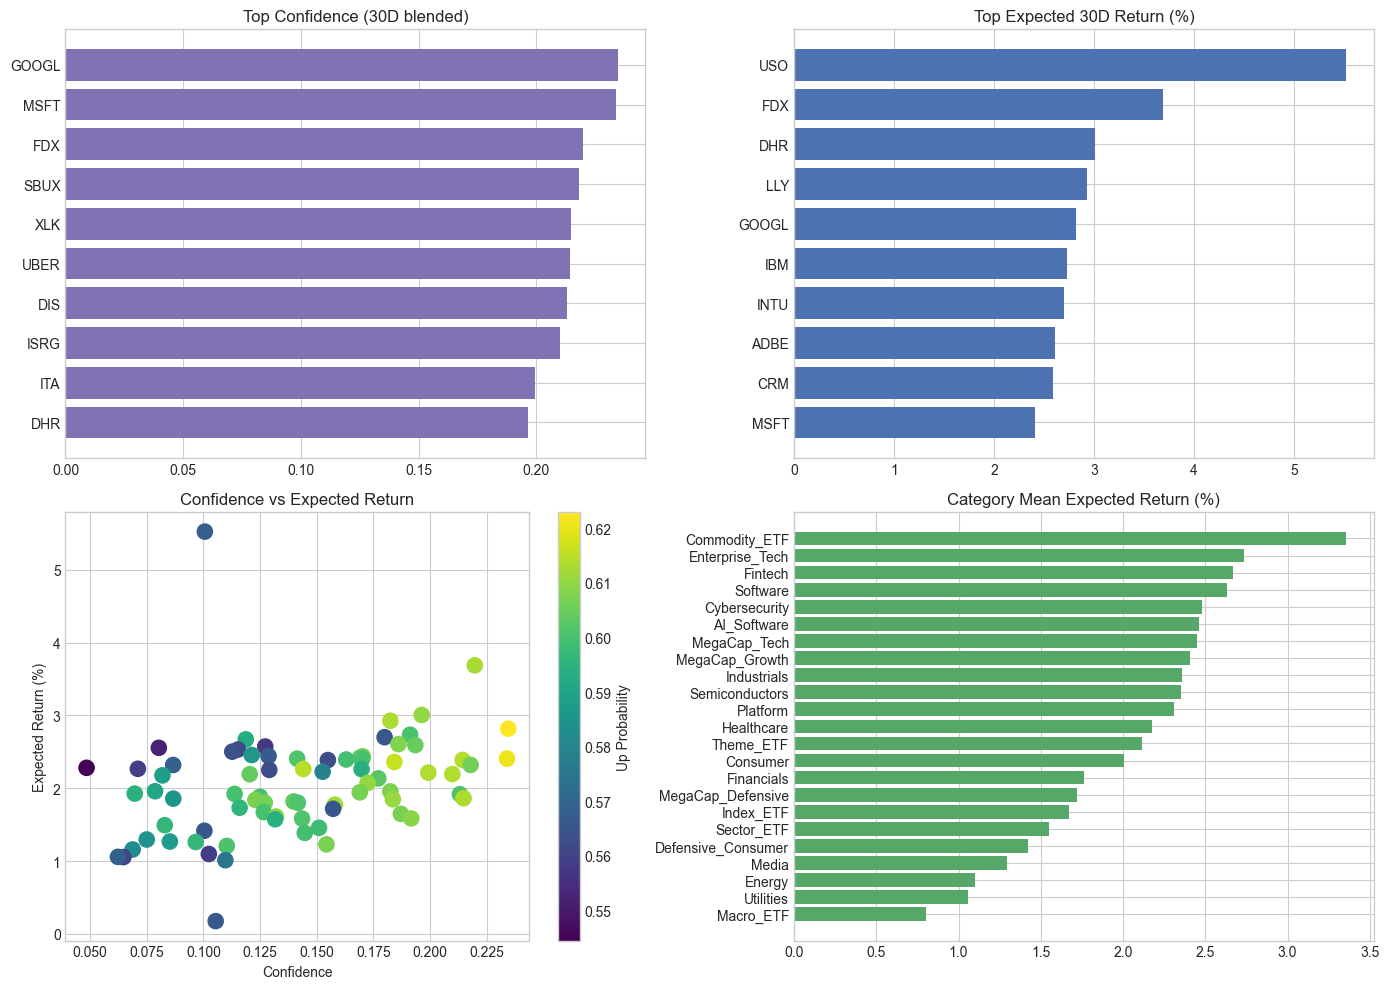

Prediction tracking: no matured predictions yet.


In [7]:
def plot_prediction_tracking(eval_df: pd.DataFrame):
    if eval_df is None or eval_df.empty:
        print("Prediction tracking: no matured predictions yet.")
        return
    fig, axes = plt.subplots(len(FORECAST_HORIZONS), 1, figsize=(15, 3.6 * len(FORECAST_HORIZONS)), sharex=False)
    if len(FORECAST_HORIZONS) == 1:
        axes = [axes]
    palette = ["#8172b3", "#4c72b0", "#55a868", "#c44e52"]
    for ax, horizon, color in zip(axes, FORECAST_HORIZONS, palette):
        horizon_df = eval_df[eval_df["horizon_days"] == horizon].copy()
        ax.set_title(f"{horizon}D Date-wise Direction Accuracy")
        if horizon_df.empty:
            ax.set_axis_off()
            ax.text(0.5, 0.5, f"No matured {horizon}D predictions yet.", ha="center", va="center", transform=ax.transAxes)
            continue
        daily = horizon_df.groupby("prediction_as_of", as_index=False).agg(
            mean_accuracy=("direction_hit", "mean"),
            std_accuracy=("direction_hit", "std"),
        ).sort_values("prediction_as_of")
        daily["std_accuracy"] = daily["std_accuracy"].fillna(0.0)
        x_pos = np.arange(len(daily))
        x_labels = daily["prediction_as_of"].dt.strftime("%y.%m.%d")
        ax.plot(x_pos, daily["mean_accuracy"], color=color, marker="o", linewidth=2.0, markersize=6, label="Mean accuracy")
        ax.errorbar(x_pos, daily["mean_accuracy"], yerr=daily["std_accuracy"], fmt="none", ecolor=color, elinewidth=1.6, capsize=6, capthick=1.6, alpha=0.95)
        tick_idx = np.arange(len(x_labels))
        if len(tick_idx) > 10:
            tick_idx = tick_idx[::max(len(tick_idx)//10, 1)]
        ax.set_xticks(tick_idx)
        ax.set_xticklabels([x_labels.iloc[i] for i in tick_idx], rotation=0, ha="center")
        ax.set_xlim(-0.5, max(len(daily) - 0.5, 0.5))
        ax.set_ylabel("Accuracy")
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.25)
        ax.legend(loc="lower left")
    axes[-1].set_xlabel("Prediction date")
    plt.tight_layout()
    plt.show()


print("Prediction summary (sorted by Adjusted_Return_%)")
show_cols = ["Stock", "Category", "Expected_Return_%"] + [f"Expected_Return_{h}D_%" for h in FORECAST_HORIZONS if h != PRIMARY_FORECAST_HORIZON] + ["Up_Probability", "Confidence", "Oversold_Rebound_Score", "Quality_Pass"]
show_cols = [c for c in show_cols if c in df_predictions.columns]
print(df_predictions[show_cols].head(TOP_N).to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax = axes[0, 0]
top_conf = df_predictions.sort_values("Confidence", ascending=False).head(10).sort_values("Confidence")
ax.barh(top_conf["Stock"], top_conf["Confidence"], color="#8172b3")
ax.set_title(f"Top Confidence ({PRIMARY_FORECAST_HORIZON}D blended)")
ax = axes[0, 1]
top_ret = df_predictions.head(10).sort_values("Expected_Return_%", ascending=True)
ax.barh(top_ret["Stock"], top_ret["Expected_Return_%"], color="#4c72b0")
ax.set_title(f"Top Expected {PRIMARY_FORECAST_HORIZON}D Return (%)")
ax = axes[1, 0]
scatter = ax.scatter(df_predictions["Confidence"], df_predictions["Expected_Return_%"], c=df_predictions["Up_Probability"], cmap="viridis", s=120)
ax.set_title("Confidence vs Expected Return")
ax.set_xlabel("Confidence")
ax.set_ylabel("Expected Return (%)")
plt.colorbar(scatter, ax=ax).set_label("Up Probability")
ax = axes[1, 1]
cat = df_predictions.groupby("Category")["Expected_Return_%"].mean().sort_values()
ax.barh(cat.index, cat.values, color="#55a868")
ax.set_title("Category Mean Expected Return (%)")
plt.tight_layout()
plt.show()

plot_prediction_tracking(df_prediction_eval_all)

## 모델 진단 및 성능 점검

In [8]:
if df_prediction_eval_all.empty:
    print("No matured prediction rows yet.")
else:
    summary = df_prediction_eval_all.groupby("horizon_days", as_index=False).agg(
        matured_predictions=("symbol", "count"),
        direction_accuracy=("direction_hit", "mean"),
        mean_abs_return_error_pct=("abs_return_error_pct", "mean"),
        mean_abs_price_error=("abs_price_error", "mean"),
    ).sort_values("horizon_days")
    for col in ["direction_accuracy", "mean_abs_return_error_pct", "mean_abs_price_error"]:
        summary[col] = summary[col].round(3)
    print(summary.to_string(index=False))
    recent = df_prediction_eval_all.sort_values(["actual_date", "horizon_days", "symbol"], ascending=[False, True, True]).head(12)
    print("\nRecently matured predictions")
    print(recent[["prediction_as_of", "actual_date", "symbol", "horizon_days", "predicted_return_pct", "actual_return_pct", "direction_hit", "abs_return_error_pct"]].to_string(index=False))

No matured prediction rows yet.


## 종합 추천 결과

In [9]:
pick_cols = ["Stock", "Asset_Name", "Category", "Confidence", "Up_Probability", "Expected_Return_%", "Adjusted_Return_%", "Quality_Pass"] + [f"Expected_Return_{h}D_%" for h in FORECAST_HORIZONS]
pick_cols = [c for c in pick_cols if c in df_predictions.columns]
display(df_predictions[pick_cols].head(TOP_N))

,Stock,Asset_Name,Category,Confidence,Up_Probability,Expected_Return_%,Adjusted_Return_%,Quality_Pass,Expected_Return_1D_%,Expected_Return_5D_%,Expected_Return_30D_%
0,USO,United States Oil Fund,Commodity_ETF,0.100674,0.567595,5.522479,3.317212,False,0.050026,0.130334,5.522479
1,FDX,FedEx,Industrials,0.219791,0.612815,3.686784,2.653714,False,0.049099,0.844695,3.686784
2,DHR,Danaher,Healthcare,0.196359,0.610040,3.006187,2.093385,False,0.053617,1.488368,3.006187
3,GOOGL,Alphabet,MegaCap_Tech,0.234537,0.622985,2.818548,2.070329,False,0.130127,1.705597,2.818548
4,LLY,Eli Lilly,Healthcare,0.182552,0.613070,2.926902,1.997763,False,0.054457,1.021233,2.926902
5,IBM,IBM,Enterprise_Tech,0.191236,0.600514,2.734849,1.890426,False,0.054405,1.028698,2.734849
6,INTU,Intuit,Software,0.179982,0.565840,2.701189,1.836761,False,0.199722,2.257021,2.701189
7,CRM,Salesforce,Software,0.193552,0.604852,2.592438,1.797990,False,0.109223,1.997801,2.592438
8,ADBE,Adobe,Software,0.186115,0.608249,2.605848,1.787913,False,0.057815,1.880528,2.605848
9,MSFT,Microsoft,MegaCap_Tech,0.233996,0.620595,2.406682,1.766495,False,0.047907,2.119078,2.406682


## 종합 요약

In [10]:
top_confidence = df_predictions.sort_values("Confidence", ascending=False).iloc[0]
top_adjusted = df_predictions.sort_values("Adjusted_Return_%", ascending=False).iloc[0]
horizon_lines = [f"- Expected {h}D return: {top_confidence.get(f'Expected_Return_{h}D_%', float('nan')):.2f}%" for h in FORECAST_HORIZONS]
summary_text = "\n".join([
    "=" * 90,
    "FINAL SUMMARY",
    "=" * 90,
    f"Highest confidence asset ({PRIMARY_FORECAST_HORIZON}D, price-only walk-forward model)",
    f"- Asset: {top_confidence['Category']} / {top_confidence['Asset_Name']} [{top_confidence['Stock']}]",
    f"- Confidence: {top_confidence['Confidence']:.2%}",
    f"- Quality pass: {bool(top_confidence['Quality_Pass'])}",
    f"- Up probability ({PRIMARY_FORECAST_HORIZON}D): {top_confidence.get('Up_Probability', float('nan')):.2%}",
    *horizon_lines,
    f"- Oversold rebound score: {top_confidence['Oversold_Rebound_Score']:.3f}",
    f"- Chart pattern score: {top_confidence['Chart_Pattern_Score']:.3f}",
    f"- Prediction as of: {top_confidence['Prediction_As_Of']}",
    "",
    "Top forecasted asset by adjusted return",
    f"- Asset: {top_adjusted['Category']} / {top_adjusted['Asset_Name']} [{top_adjusted['Stock']}]",
    f"- Adjusted return: {top_adjusted['Adjusted_Return_%']:.2f}%",
    f"- Confidence: {top_adjusted['Confidence']:.2%}",
    "",
    f"- Logged predictions: {len(df_prediction_log_all):,}",
    f"- Evaluated predictions: {len(df_prediction_eval_all):,}",
    "=" * 90,
])
print(summary_text)

FINAL SUMMARY
Highest confidence asset (30D, price-only walk-forward model)
- Asset: MegaCap_Tech / Alphabet [GOOGL]
- Confidence: 23.45%
- Quality pass: False
- Up probability (30D): 62.30%
- Expected 1D return: 0.13%
- Expected 5D return: 1.71%
- Expected 30D return: 2.82%
- Oversold rebound score: 2.219
- Chart pattern score: -8.079
- Prediction as of: 2026-03-27 00:00:00+00:00

Top forecasted asset by adjusted return
- Asset: Commodity_ETF / United States Oil Fund [USO]
- Adjusted return: 3.32%
- Confidence: 10.07%

- Logged predictions: 11,931
- Evaluated predictions: 0


## 데이터 커버리지 점검

In [11]:
coverage = df_features.groupby("symbol", as_index=False).agg(
    rows=("date", "count"),
    first_date=("date", "min"),
    last_date=("date", "max"),
)
coverage["history_days"] = (coverage["last_date"] - coverage["first_date"]).dt.days
display(coverage.sort_values("rows", ascending=False).head(20))
print(f"Coverage rows: {len(coverage):,}")

,symbol,rows,first_date,last_date,history_days
3,ADBE,7549,1996-03-27 00:00:00+00:00,2026-03-27 00:00:00+00:00,10957
10,BA,7549,1996-03-27 00:00:00+00:00,2026-03-27 00:00:00+00:00,10957
5,AMD,7549,1996-03-27 00:00:00+00:00,2026-03-27 00:00:00+00:00,10957
4,AMAT,7549,1996-03-27 00:00:00+00:00,2026-03-27 00:00:00+00:00,10957
31,HON,7549,1996-03-27 00:00:00+00:00,2026-03-27 00:00:00+00:00,10957
30,HD,7549,1996-03-27 00:00:00+00:00,2026-03-27 00:00:00+00:00,10957
33,IBM,7549,1996-03-27 00:00:00+00:00,2026-03-27 00:00:00+00:00,10957
8,ASML,7549,1996-03-27 00:00:00+00:00,2026-03-27 00:00:00+00:00,10957
14,CAT,7549,1996-03-27 00:00:00+00:00,2026-03-27 00:00:00+00:00,10957
25,FDX,7549,1996-03-27 00:00:00+00:00,2026-03-27 00:00:00+00:00,10957


Coverage rows: 100
